
# RETRAIN REFUGE Fusion Classification: ROI CDR EfficientNetB4 + Predicted Blood Vessel


Tujuan notebook:
- membaca citra REFUGE, mask cup-disc hasil segmentasi EfficientNetB4, predicted vessel mask, dan label,
- membuat ROI optic disc / cup-disc,
- menghitung fitur numerik CDR dari mask cup-disc EfficientNetB4,
- membangun model klasifikasi fusion ROI CDR + predicted vessel + fitur CDR,
- memakai Stratified 5-Fold karena label tidak seimbang,
- memakai class weight + oversampling glaucoma + threshold tuning untuk meminimalkan salah deteksi glaucoma.

Struktur folder yang diasumsikan:

```text
/content/drive/MyDrive/BV_CDR/
├── REFUG_raw/
│   ├── images/
│   ├── masks_cup/  (ground truth, tidak dipakai untuk klasifikasi)
│   ├── masks_disc/ (ground truth, tidak dipakai untuk klasifikasi)
│   └── labels/refuge_labels.xlsx
│
├── pred_mask_cup_disc_efficientnetb4/
│   ├── pred_cup/
│   └── pred_disc/
│
├── predictions/refuge/masks_pred/
│   ├── REFUGE1-train-1.png
│   └── ...
│
└── models/
```


Output versi threshold seimbang disimpan pada:

```text
/content/drive/MyDrive/BV_CDR/Klasifikasi_EFFB4/
├── processed/
├── models/
└── results/
```


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip -q install openpyxl scikit-learn

In [ ]:
import os
import glob
import random
import json
import math
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score
)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import os

BASE_DIR = "/content/drive/MyDrive/BV_CDR"

CUP_DISC_ENCODER = "efficientnetb4"


REFUGE_RAW_DIR = os.path.join(BASE_DIR, "REFUG_raw")
IMAGE_DIR = os.path.join(REFUGE_RAW_DIR, "images")

LABEL_XLSX = os.path.join(REFUGE_RAW_DIR, "labels", "refuge_labels.xlsx")
LABEL_CSV  = os.path.join(REFUGE_RAW_DIR, "labels", "refuge_labels.csv")

# predicted cd mask
CUP_DIR = os.path.join(BASE_DIR, "FIX4_pred_mask_cup_disc_efficientnetb4", "pred_cup")
DISC_DIR = os.path.join(BASE_DIR, "FIX4_pred_mask_cup_disc_efficientnetb4", "pred_disc")

# predicted vessel
VESSEL_PRED_DIR = os.path.join(BASE_DIR, "predictions", "refuge", "masks_pred")


OUTPUT_ROOT = os.path.join(BASE_DIR, "Klasifikasi_EFFB4")

FUSION_DIR = os.path.join(OUTPUT_ROOT, "processed", "refuge_fusion_predmask_efficientnetb4")
FUSION_PREVIEW_DIR = os.path.join(FUSION_DIR, "previews")

FUSION_META_PATH = os.path.join(FUSION_DIR, "refuge_fusion_metadata_predmask_efficientnetb4.csv")
FUSION_NPZ_PATH = os.path.join(FUSION_DIR, "refuge_fusion_dataset_224_predmask_efficientnetb4.npz")

os.makedirs(FUSION_DIR, exist_ok=True)
os.makedirs(FUSION_PREVIEW_DIR, exist_ok=True)

MODEL_OUT_DIR = os.path.join(OUTPUT_ROOT, "models")
RESULT_OUT_DIR = os.path.join(OUTPUT_ROOT, "results")
PLOT_OUT_DIR = os.path.join(RESULT_OUT_DIR, "plots")
METRIC_OUT_DIR = os.path.join(RESULT_OUT_DIR, "metrics")
CM_OUT_DIR = os.path.join(RESULT_OUT_DIR, "confusion_matrix")

for d in [OUTPUT_ROOT, MODEL_OUT_DIR, RESULT_OUT_DIR, PLOT_OUT_DIR, METRIC_OUT_DIR, CM_OUT_DIR]:
    os.makedirs(d, exist_ok=True)

IMG_SIZE = 224
N_SPLITS = 5
EPOCHS = 40
BATCH_SIZE = 8
LEARNING_RATE = 1e-4
USE_OVERSAMPLING_GLAUCOMA = True
USE_CLASS_WEIGHT = True.
TARGET_SENSITIVITY = 0.85
MIN_SPECIFICITY = 0.85
RANDOM_SEED = 42

print("CUP_DIR:", CUP_DIR)
print("DISC_DIR:", DISC_DIR)
print("OUTPUT_ROOT:", OUTPUT_ROOT)
print("FUSION_DIR:", FUSION_DIR)
print("FUSION_META_PATH:", FUSION_META_PATH)
print("FUSION_NPZ_PATH:", FUSION_NPZ_PATH)
print("MODEL_OUT_DIR:", MODEL_OUT_DIR)
print("RESULT_OUT_DIR:", RESULT_OUT_DIR)
print("TARGET_SENSITIVITY:", TARGET_SENSITIVITY)
print("MIN_SPECIFICITY:", MIN_SPECIFICITY)

CUP_DIR: /content/drive/MyDrive/BV_CDR/FIX4_pred_mask_cup_disc_efficientnetb4/pred_cup
DISC_DIR: /content/drive/MyDrive/BV_CDR/FIX4_pred_mask_cup_disc_efficientnetb4/pred_disc
OUTPUT_ROOT: /content/drive/MyDrive/BV_CDR/Klasifikasi_EFFB4
FUSION_DIR: /content/drive/MyDrive/BV_CDR/Klasifikasi_EFFB4/processed/refuge_fusion_predmask_efficientnetb4
FUSION_META_PATH: /content/drive/MyDrive/BV_CDR/Klasifikasi_EFFB4/processed/refuge_fusion_predmask_efficientnetb4/refuge_fusion_metadata_predmask_efficientnetb4.csv
FUSION_NPZ_PATH: /content/drive/MyDrive/BV_CDR/Klasifikasi_EFFB4/processed/refuge_fusion_predmask_efficientnetb4/refuge_fusion_dataset_224_predmask_efficientnetb4.npz
MODEL_OUT_DIR: /content/drive/MyDrive/BV_CDR/Klasifikasi_EFFB4/models
RESULT_OUT_DIR: /content/drive/MyDrive/BV_CDR/Klasifikasi_EFFB4/results
TARGET_SENSITIVITY: 0.85
MIN_SPECIFICITY: 0.85


In [ ]:
from glob import glob

check_paths = {
    "BASE_DIR": BASE_DIR,
    "OUTPUT_ROOT": OUTPUT_ROOT,
    "REFUGE_RAW_DIR": REFUGE_RAW_DIR,
    "IMAGE_DIR": IMAGE_DIR,
    "CUP_DIR": CUP_DIR,
    "DISC_DIR": DISC_DIR,
    "LABEL_XLSX": LABEL_XLSX,
    "LABEL_CSV": LABEL_CSV,
    "VESSEL_PRED_DIR": VESSEL_PRED_DIR,
    "FUSION_DIR": FUSION_DIR,
    "FUSION_PREVIEW_DIR": FUSION_PREVIEW_DIR,
    "MODEL_OUT_DIR": MODEL_OUT_DIR,
    "RESULT_OUT_DIR": RESULT_OUT_DIR,
    "PLOT_OUT_DIR": PLOT_OUT_DIR,
    "METRIC_OUT_DIR": METRIC_OUT_DIR,
    "CM_OUT_DIR": CM_OUT_DIR,
}

for name, path in check_paths.items():
    print("=" * 70)
    print(name)
    print(path)

    if os.path.exists(path):
        print("Status: ADA")

        if os.path.isdir(path):
            files = os.listdir(path)
            print("Jumlah isi:", len(files))
            print("Contoh isi:", files[:5])
        else:
            print("Ini file")
    else:
        print("Status: TIDAK ADA")

BASE_DIR
/content/drive/MyDrive/BV_CDR
Status: ADA
Jumlah isi: 21
Contoh isi: ['raw', 'processed', 'models', 'results', 'predictions']
OUTPUT_ROOT
/content/drive/MyDrive/BV_CDR/Klasifikasi_EFFB4
Status: ADA
Jumlah isi: 3
Contoh isi: ['processed', 'models', 'results']
REFUGE_RAW_DIR
/content/drive/MyDrive/BV_CDR/REFUG_raw
Status: ADA
Jumlah isi: 4
Contoh isi: ['masks_cup', 'images', 'masks_disc', 'labels']
IMAGE_DIR
/content/drive/MyDrive/BV_CDR/REFUG_raw/images
Status: ADA
Jumlah isi: 400
Contoh isi: ['REFUGE1-train-149.png', 'REFUGE1-train-115.png', 'REFUGE1-train-156.png', 'REFUGE1-train-150.png', 'REFUGE1-train-151.png']
CUP_DIR
/content/drive/MyDrive/BV_CDR/FIX4_pred_mask_cup_disc_efficientnetb4/pred_cup
Status: ADA
Jumlah isi: 400
Contoh isi: ['REFUGE1-train-1.png', 'REFUGE1-train-10.png', 'REFUGE1-train-100.png', 'REFUGE1-train-101.png', 'REFUGE1-train-102.png']
DISC_DIR
/content/drive/MyDrive/BV_CDR/FIX4_pred_mask_cup_disc_efficientnetb4/pred_disc
Status: ADA
Jumlah isi: 400
Con

In [ ]:
import os

def get_names(folder):
    return set([
        os.path.splitext(f)[0]
        for f in os.listdir(folder)
        if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"))
    ])

image_names = get_names(IMAGE_DIR)
cup_names = get_names(CUP_DIR)
disc_names = get_names(DISC_DIR)
vessel_names = get_names(VESSEL_PRED_DIR)

print("Jumlah image :", len(image_names))
print("Jumlah cup   :", len(cup_names))
print("Jumlah disc  :", len(disc_names))
print("Jumlah vessel:", len(vessel_names))

common_names = image_names & cup_names & disc_names & vessel_names
print("Jumlah file yang match semua:", len(common_names))

print("\nImage tidak ada cup:", len(image_names - cup_names))
print("Image tidak ada disc:", len(image_names - disc_names))
print("Image tidak ada vessel:", len(image_names - vessel_names))

print("\nContoh yang match:")
print(sorted(list(common_names))[:10])

Jumlah image : 400
Jumlah cup   : 400
Jumlah disc  : 400
Jumlah vessel: 400
Jumlah file yang match semua: 400

Image tidak ada cup: 0
Image tidak ada disc: 0
Image tidak ada vessel: 0

Contoh yang match:
['REFUGE1-train-1', 'REFUGE1-train-10', 'REFUGE1-train-100', 'REFUGE1-train-101', 'REFUGE1-train-102', 'REFUGE1-train-103', 'REFUGE1-train-104', 'REFUGE1-train-105', 'REFUGE1-train-106', 'REFUGE1-train-107']


In [ ]:
import os
from glob import glob

assert os.path.exists(IMAGE_DIR), f"Folder image tidak ditemukan: {IMAGE_DIR}"
assert os.path.exists(CUP_DIR), f"Folder masks_cup tidak ditemukan: {CUP_DIR}"
assert os.path.exists(DISC_DIR), f"Folder masks_disc tidak ditemukan: {DISC_DIR}"
assert os.path.exists(VESSEL_PRED_DIR), f"Folder predicted vessel tidak ditemukan: {VESSEL_PRED_DIR}"
assert os.path.exists(LABEL_XLSX) or os.path.exists(LABEL_CSV), "File label REFUGE tidak ditemukan."

image_paths = sorted(glob(os.path.join(IMAGE_DIR, "*")))
image_paths = [p for p in image_paths if os.path.isfile(p)]

print("Jumlah image:", len(image_paths))
print("Contoh image:")
for p in image_paths[:5]:
    print("-", os.path.basename(p))

Jumlah image: 400
Contoh image:
- REFUGE1-train-1.png
- REFUGE1-train-10.png
- REFUGE1-train-100.png
- REFUGE1-train-101.png
- REFUGE1-train-102.png


In [ ]:
# load refuge
def load_labels():
    if os.path.exists(LABEL_XLSX):
        df = pd.read_excel(LABEL_XLSX)
    else:
        df = pd.read_csv(LABEL_CSV)

    df.columns = [str(c).strip() for c in df.columns]

    possible_name_cols = ["NAME", "Name", "name", "filename", "FILENAME", "file", "FILE"]
    possible_label_cols = ["LABELS", "Labels", "labels", "label", "LABEL", "class", "CLASS"]

    name_col = next((c for c in possible_name_cols if c in df.columns), None)
    label_col = next((c for c in possible_label_cols if c in df.columns), None)

    if name_col is None or label_col is None:
        raise ValueError(f"Kolom nama/label tidak ditemukan. Kolom yang ada: {df.columns.tolist()}")

    out = df[[name_col, label_col]].copy()
    out = out.rename(columns={name_col: "name_no_ext", label_col: "label"})
    out["name_no_ext"] = out["name_no_ext"].astype(str)
    out["name_no_ext"] = out["name_no_ext"].str.replace(".png", "", regex=False)
    out["name_no_ext"] = out["name_no_ext"].str.replace(".jpg", "", regex=False)
    out["name_no_ext"] = out["name_no_ext"].str.replace(".jpeg", "", regex=False)

    def map_label(x):
        if isinstance(x, str):
            xs = x.strip().lower()
            if xs in ["1", "glaucoma", "g", "positive", "suspect", "suspected"]:
                return 1
            if xs in ["0", "normal", "healthy", "n", "negative"]:
                return 0
        return int(x)

    out["label"] = out["label"].apply(map_label).astype(int)
    return out

labels_df = load_labels()
print(labels_df.head())
print("\nDistribusi label:")
print(labels_df["label"].value_counts().sort_index())


       name_no_ext  label
0  REFUGE1-train-1      1
1  REFUGE1-train-2      1
2  REFUGE1-train-3      1
3  REFUGE1-train-4      1
4  REFUGE1-train-5      1

Distribusi label:
label
0    360
1     40
Name: count, dtype: int64


In [ ]:
# buat pasangan refuge
import os
import pandas as pd
import glob as glob_module

def stem(path):
    return os.path.splitext(os.path.basename(path))[0]

image_dict = {
    stem(p): p
    for p in glob_module.glob(os.path.join(IMAGE_DIR, "*"))
    if os.path.isfile(p)
}

cup_dict = {
    stem(p): p
    for p in glob_module.glob(os.path.join(CUP_DIR, "*"))
    if os.path.isfile(p)
}

disc_dict = {
    stem(p): p
    for p in glob_module.glob(os.path.join(DISC_DIR, "*"))
    if os.path.isfile(p)
}

vessel_dict = {
    stem(p): p
    for p in glob_module.glob(os.path.join(VESSEL_PRED_DIR, "*"))
    if os.path.isfile(p)
}

rows = []
missing = []

for _, r in labels_df.iterrows():
    name = r["name_no_ext"]
    label = int(r["label"])

    if name not in image_dict:
        missing.append((name, "image"))
        continue

    if name not in cup_dict:
        missing.append((name, "cup"))
        continue

    if name not in disc_dict:
        missing.append((name, "disc"))
        continue

    if name not in vessel_dict:
        missing.append((name, "vessel_pred"))
        continue

    rows.append({
        "name_no_ext": name,
        "filename": os.path.basename(image_dict[name]),
        "image_path": image_dict[name],
        "cup_path": cup_dict[name],
        "disc_path": disc_dict[name],
        "vessel_pred_path": vessel_dict[name],
        "label": label
    })

pairs_df = pd.DataFrame(rows)

print("Jumlah pasangan lengkap:", len(pairs_df))
print("Jumlah missing:", len(missing))

if missing:
    print("Contoh missing:", missing[:20])

print("\nDistribusi label pasangan lengkap:")
print(pairs_df["label"].value_counts().sort_index())

pairs_df.head()

Jumlah pasangan lengkap: 400
Jumlah missing: 0

Distribusi label pasangan lengkap:
label
0    360
1     40
Name: count, dtype: int64


,name_no_ext,filename,image_path,cup_path,disc_path,vessel_pred_path,label
0,REFUGE1-train-1,REFUGE1-train-1.png,/content/drive/MyDrive/BV_CDR/REFUG_raw/images...,/content/drive/MyDrive/BV_CDR/FIX4_pred_mask_c...,/content/drive/MyDrive/BV_CDR/FIX4_pred_mask_c...,/content/drive/MyDrive/BV_CDR/predictions/refu...,1
1,REFUGE1-train-2,REFUGE1-train-2.png,/content/drive/MyDrive/BV_CDR/REFUG_raw/images...,/content/drive/MyDrive/BV_CDR/FIX4_pred_mask_c...,/content/drive/MyDrive/BV_CDR/FIX4_pred_mask_c...,/content/drive/MyDrive/BV_CDR/predictions/refu...,1
2,REFUGE1-train-3,REFUGE1-train-3.png,/content/drive/MyDrive/BV_CDR/REFUG_raw/images...,/content/drive/MyDrive/BV_CDR/FIX4_pred_mask_c...,/content/drive/MyDrive/BV_CDR/FIX4_pred_mask_c...,/content/drive/MyDrive/BV_CDR/predictions/refu...,1
3,REFUGE1-train-4,REFUGE1-train-4.png,/content/drive/MyDrive/BV_CDR/REFUG_raw/images...,/content/drive/MyDrive/BV_CDR/FIX4_pred_mask_c...,/content/drive/MyDrive/BV_CDR/FIX4_pred_mask_c...,/content/drive/MyDrive/BV_CDR/predictions/refu...,1
4,REFUGE1-train-5,REFUGE1-train-5.png,/content/drive/MyDrive/BV_CDR/REFUG_raw/images...,/content/drive/MyDrive/BV_CDR/FIX4_pred_mask_c...,/content/drive/MyDrive/BV_CDR/FIX4_pred_mask_c...,/content/drive/MyDrive/BV_CDR/predictions/refu...,1


In [ ]:
SPLITS_SAVE_DIR = os.path.join(BASE_DIR, "splits_REf")
os.makedirs(SPLITS_SAVE_DIR, exist_ok=True)

splits_csv_path = os.path.join(SPLITS_SAVE_DIR, "pairs_df_splits.csv")
pairs_df.to_csv(splits_csv_path, index=False)

print(f"pairs_df saved to: {splits_csv_path}")

pairs_df saved to: /content/drive/MyDrive/BV_CDR/splits_REf/pairs_df_splits.csv


In [ ]:
# mengehitung acdr, vcdr, hcdr, vessel density roi dan vessel density disc

def read_rgb(path):
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f"Gagal membaca image: {path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def read_gray(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Gagal membaca mask: {path}")
    return img

def binarize_mask(mask):
    return (mask > 0).astype(np.uint8)

def get_bbox(mask_bin):
    ys, xs = np.where(mask_bin > 0)
    if len(xs) == 0 or len(ys) == 0:
        return None
    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()
    return x1, y1, x2, y2

def expand_bbox(bbox, img_w, img_h, pad_ratio=0.35):
    x1, y1, x2, y2 = bbox
    bw = x2 - x1 + 1
    bh = y2 - y1 + 1
    pad = int(max(bw, bh) * pad_ratio)

    cx = (x1 + x2) // 2
    cy = (y1 + y2) // 2
    half = int(max(bw, bh) / 2 + pad)

    nx1 = max(0, cx - half)
    ny1 = max(0, cy - half)
    nx2 = min(img_w - 1, cx + half)
    ny2 = min(img_h - 1, cy + half)
    return nx1, ny1, nx2, ny2

def center_crop_bbox(img_w, img_h, crop_ratio=0.6):
    side = int(min(img_w, img_h) * crop_ratio)
    cx, cy = img_w // 2, img_h // 2
    x1 = max(0, cx - side // 2)
    y1 = max(0, cy - side // 2)
    x2 = min(img_w - 1, cx + side // 2)
    y2 = min(img_h - 1, cy + side // 2)
    return x1, y1, x2, y2

def crop_by_bbox(arr, bbox):
    x1, y1, x2, y2 = bbox
    return arr[y1:y2+1, x1:x2+1]

def resize_rgb(img, size=224):
    return cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)

def resize_mask(mask, size=224):
    return cv2.resize(mask, (size, size), interpolation=cv2.INTER_NEAREST)

def safe_ratio(a, b):
    if b == 0:
        return 0.0
    return float(a) / float(b)

def bbox_width_height(mask_bin):
    bbox = get_bbox(mask_bin)
    if bbox is None:
        return 0, 0
    x1, y1, x2, y2 = bbox
    return x2 - x1 + 1, y2 - y1 + 1

def compute_features(cup_bin, disc_bin, vessel_bin):
    cup_area = int(np.sum(cup_bin > 0))
    disc_area = int(np.sum(disc_bin > 0))

    cup_w, cup_h = bbox_width_height(cup_bin)
    disc_w, disc_h = bbox_width_height(disc_bin)

    acdr = safe_ratio(cup_area, disc_area)
    vcdr = safe_ratio(cup_h, disc_h)
    hcdr = safe_ratio(cup_w, disc_w)

    vessel_pixels = int(np.sum(vessel_bin > 0))
    vessel_density_full = safe_ratio(vessel_pixels, vessel_bin.size)

    if disc_area > 0:
        vessel_density_disc = safe_ratio(np.sum((vessel_bin > 0) & (disc_bin > 0)), disc_area)
    else:
        vessel_density_disc = 0.0

    return {
        "cup_area": cup_area,
        "disc_area": disc_area,
        "ACDR": acdr,
        "VCDR": vcdr,
        "HCDR": hcdr,
        "vessel_density_full": vessel_density_full,
        "vessel_density_disc": vessel_density_disc
    }


In [ ]:
def read_rgb(path):
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f"Gagal membaca image: {path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def read_gray(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Gagal membaca mask: {path}")
    return img

def binarize_mask(mask):
    return (mask > 0).astype(np.uint8)

def get_bbox(mask_bin):
    ys, xs = np.where(mask_bin > 0)
    if len(xs) == 0 or len(ys) == 0:
        return None
    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()
    return x1, y1, x2, y2

def expand_bbox(bbox, img_w, img_h, pad_ratio=0.35):
    x1, y1, x2, y2 = bbox
    bw = x2 - x1 + 1
    bh = y2 - y1 + 1
    pad = int(max(bw, bh) * pad_ratio)

    cx = (x1 + x2) // 2
    cy = (y1 + y2) // 2
    half = int(max(bw, bh) / 2 + pad)

    nx1 = max(0, cx - half)
    ny1 = max(0, cy - half)
    nx2 = min(img_w - 1, cx + half)
    ny2 = min(img_h - 1, cy + half)
    return nx1, ny1, nx2, ny2

def center_crop_bbox(img_w, img_h, crop_ratio=0.6):
    side = int(min(img_w, img_h) * crop_ratio)
    cx, cy = img_w // 2, img_h // 2
    x1 = max(0, cx - side // 2)
    y1 = max(0, cy - side // 2)
    x2 = min(img_w - 1, cx + side // 2)
    y2 = min(img_h - 1, cy + side // 2)
    return x1, y1, x2, y2

def crop_by_bbox(arr, bbox):
    x1, y1, x2, y2 = bbox
    return arr[y1:y2+1, x1:x2+1]

def resize_rgb(img, size=224):
    return cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)

def resize_mask(mask, size=224):
    return cv2.resize(mask, (size, size), interpolation=cv2.INTER_NEAREST)

def safe_ratio(a, b):
    if b == 0:
        return 0.0
    return float(a) / float(b)

def bbox_width_height(mask_bin):
    bbox = get_bbox(mask_bin)
    if bbox is None:
        return 0, 0
    x1, y1, x2, y2 = bbox
    return x2 - x1 + 1, y2 - y1 + 1

def compute_features(cup_bin, disc_bin, vessel_bin):
    cup_area = int(np.sum(cup_bin > 0))
    disc_area = int(np.sum(disc_bin > 0))

    cup_w, cup_h = bbox_width_height(cup_bin)
    disc_w, disc_h = bbox_width_height(disc_bin)

    acdr = safe_ratio(cup_area, disc_area)
    vcdr = safe_ratio(cup_h, disc_h)
    hcdr = safe_ratio(cup_w, disc_w)

    vessel_pixels = int(np.sum(vessel_bin > 0))
    vessel_density_full = safe_ratio(vessel_pixels, vessel_bin.size)

    if disc_area > 0:
        vessel_density_disc = safe_ratio(np.sum((vessel_bin > 0) & (disc_bin > 0)), disc_area)
    else:
        vessel_density_disc = 0.0

    return {
        "cup_area": cup_area,
        "disc_area": disc_area,
        "ACDR": acdr,
        "VCDR": vcdr,
        "HCDR": hcdr,
        "vessel_density_full": vessel_density_full,
        "vessel_density_disc": vessel_density_disc
    }

In [ ]:
import os

BASE_DIR_NORM = os.path.normpath(BASE_DIR)
FUSION_NPZ_NORM = os.path.normpath(FUSION_NPZ_PATH)
FUSION_META_NORM = os.path.normpath(FUSION_META_PATH)

print("BASE_DIR:", BASE_DIR_NORM)
print("FUSION_NPZ_PATH:", FUSION_NPZ_NORM)
print("FUSION_META_PATH:", FUSION_META_NORM)

print("\nContoh path dari pairs_df:")
print("image :", pairs_df.loc[0, "image_path"])
print("cup   :", pairs_df.loc[0, "cup_path"])
print("disc  :", pairs_df.loc[0, "disc_path"])
print("vessel:", pairs_df.loc[0, "vessel_pred_path"])

assert BASE_DIR_NORM.endswith("BV_CDR"), "BASE_DIR masih salah"
assert FUSION_NPZ_NORM.startswith(BASE_DIR_NORM), "FUSION_NPZ_PATH masih salah"
assert FUSION_META_NORM.startswith(BASE_DIR_NORM), "FUSION_META_PATH masih salah"

assert "FIX4_pred_mask_cup_disc_efficientnetb4/pred_cup" in pairs_df.loc[0, "cup_path"], "cup_path masih path lama"
assert "FIX4_pred_mask_cup_disc_efficientnetb4/pred_disc" in pairs_df.loc[0, "disc_path"], "disc_path masih path lama"

assert "REFUG_raw/masks_cup" not in pairs_df.loc[0, "cup_path"], "cup_path masih pakai masks_cup lama"
assert "REFUG_raw/masks_disc" not in pairs_df.loc[0, "disc_path"], "disc_path masih pakai masks_disc lama"

print("\n✅ Semua path sebelum build fusion sudah benar")

BASE_DIR: /content/drive/MyDrive/BV_CDR
FUSION_NPZ_PATH: /content/drive/MyDrive/BV_CDR/Klasifikasi_EFFB4/processed/refuge_fusion_predmask_efficientnetb4/refuge_fusion_dataset_224_predmask_efficientnetb4.npz
FUSION_META_PATH: /content/drive/MyDrive/BV_CDR/Klasifikasi_EFFB4/processed/refuge_fusion_predmask_efficientnetb4/refuge_fusion_metadata_predmask_efficientnetb4.csv

Contoh path dari pairs_df:
image : /content/drive/MyDrive/BV_CDR/REFUG_raw/images/REFUGE1-train-1.png
cup   : /content/drive/MyDrive/BV_CDR/FIX4_pred_mask_cup_disc_efficientnetb4/pred_cup/REFUGE1-train-1.png
disc  : /content/drive/MyDrive/BV_CDR/FIX4_pred_mask_cup_disc_efficientnetb4/pred_disc/REFUGE1-train-1.png
vessel: /content/drive/MyDrive/BV_CDR/predictions/refuge/masks_pred/REFUGE1-train-1.png

✅ Semua path sebelum build fusion sudah benar


In [ ]:
# datset fusion, roi_images, vessel_rois, num_feature, labels

import os
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

def build_fusion_dataset(pairs_df, img_size=224, force_rebuild=True):
    print("FUSION_NPZ_PATH :", FUSION_NPZ_PATH)
    print("FUSION_META_PATH:", FUSION_META_PATH)

    # Kalau file sudah ada dan tidak dipaksa rebuild, baru load
    if os.path.exists(FUSION_NPZ_PATH) and os.path.exists(FUSION_META_PATH) and not force_rebuild:
        print("\nDataset fusion sudah ada. Load dari file:")
        print(FUSION_NPZ_PATH)

        data = np.load(FUSION_NPZ_PATH, allow_pickle=True)
        meta_df = pd.read_csv(FUSION_META_PATH)

        print("\nCek metadata yang diload:")
        print("cup :", meta_df.loc[0, "cup_path"])
        print("disc:", meta_df.loc[0, "disc_path"])

        return data, meta_df

    print("\nBuilding fusion dataset baru...")

    roi_images = []
    vessel_rois = []
    num_features = []
    labels = []
    meta_rows = []

    for row in tqdm(pairs_df.itertuples(index=False), total=len(pairs_df), desc="Building fusion dataset"):
        image_path = row.image_path
        cup_path = row.cup_path
        disc_path = row.disc_path
        vessel_pred_path = row.vessel_pred_path

        # WAJIB: cegah path lama masuk lagi
        assert "FIX4_pred_mask_cup_disc_efficientnetb4/pred_cup" in cup_path, f"cup_path masih salah: {cup_path}"
        assert "FIX4_pred_mask_cup_disc_efficientnetb4/pred_disc" in disc_path, f"disc_path masih salah: {disc_path}"
        assert "REFUG_raw/masks_cup" not in cup_path, f"cup_path masih lama: {cup_path}"
        assert "REFUG_raw/masks_disc" not in disc_path, f"disc_path masih lama: {disc_path}"

        image = read_rgb(image_path)
        cup = binarize_mask(read_gray(cup_path))
        disc = binarize_mask(read_gray(disc_path))
        vessel = binarize_mask(read_gray(vessel_pred_path))

        h, w = image.shape[:2]

        if cup.shape[:2] != (h, w):
            cup = cv2.resize(cup, (w, h), interpolation=cv2.INTER_NEAREST)

        if disc.shape[:2] != (h, w):
            disc = cv2.resize(disc, (w, h), interpolation=cv2.INTER_NEAREST)

        if vessel.shape[:2] != (h, w):
            vessel = cv2.resize(vessel, (w, h), interpolation=cv2.INTER_NEAREST)

        disc_bbox = get_bbox(disc)

        if disc_bbox is None:
            roi_bbox = center_crop_bbox(w, h)
        else:
            roi_bbox = expand_bbox(disc_bbox, w, h, pad_ratio=0.35)

        image_roi = crop_by_bbox(image, roi_bbox)
        vessel_roi = crop_by_bbox(vessel, roi_bbox)

        image_roi_resized = resize_rgb(image_roi, img_size)
        vessel_roi_resized = resize_mask(vessel_roi, img_size)

        feat = compute_features(cup, disc, vessel)
        feat["vessel_density_roi"] = safe_ratio(np.sum(vessel_roi > 0), vessel_roi.size)

        roi_images.append(image_roi_resized.astype(np.float32))
        vessel_rois.append(vessel_roi_resized[..., None].astype(np.float32))

        num_features.append([
            feat["ACDR"],
            feat["VCDR"],
            feat["HCDR"],
            feat["vessel_density_roi"],
            feat["vessel_density_disc"],
            feat["vessel_density_full"]
        ])

        labels.append(int(row.label))

        meta = {
            "name_no_ext": row.name_no_ext,
            "filename": row.filename,
            "image_path": image_path,
            "cup_path": cup_path,
            "disc_path": disc_path,
            "vessel_pred_path": vessel_pred_path,
            "label": int(row.label),
            "roi_x1": roi_bbox[0],
            "roi_y1": roi_bbox[1],
            "roi_x2": roi_bbox[2],
            "roi_y2": roi_bbox[3],
            "cup_area": feat["cup_area"],
            "disc_area": feat["disc_area"],
            "ACDR": feat["ACDR"],
            "VCDR": feat["VCDR"],
            "HCDR": feat["HCDR"],
            "vessel_density_full": feat["vessel_density_full"],
            "vessel_density_disc": feat["vessel_density_disc"],
            "vessel_density_roi": feat["vessel_density_roi"],
        }

        meta_rows.append(meta)

    roi_images = np.stack(roi_images).astype(np.float32)
    vessel_rois = np.stack(vessel_rois).astype(np.float32)
    num_features = np.array(num_features, dtype=np.float32)
    labels = np.array(labels, dtype=np.int32)
    meta_df = pd.DataFrame(meta_rows)

    np.savez_compressed(
        FUSION_NPZ_PATH,
        roi_images=roi_images,
        vessel_rois=vessel_rois,
        num_features=num_features,
        labels=labels,
        names=meta_df["name_no_ext"].values
    )

    meta_df.to_csv(FUSION_META_PATH, index=False)

    print("\nSaved:", FUSION_NPZ_PATH)
    print("Saved:", FUSION_META_PATH)

    print("\nCek metadata baru:")
    print("cup :", meta_df.loc[0, "cup_path"])
    print("disc:", meta_df.loc[0, "disc_path"])

    print("\nCek path lama:")
    print("cup lama? :", meta_df["cup_path"].str.contains("REFUG_raw/masks_cup").any())
    print("disc lama?:", meta_df["disc_path"].str.contains("REFUG_raw/masks_disc").any())

    print("\nCek path baru:")
    print("cup baru? :", meta_df["cup_path"].str.contains("pred_mask_cup_disc_efficientnetb4/pred_cup").all())
    print("disc baru?:", meta_df["disc_path"].str.contains("pred_mask_cup_disc_efficientnetb4/pred_disc").all())

    data = np.load(FUSION_NPZ_PATH, allow_pickle=True)

    return data, meta_df

si
fusion_data, fusion_meta = build_fusion_dataset(
    pairs_df,
    img_size=IMG_SIZE,
    force_rebuild=True
)

X_roi = fusion_data["roi_images"]
X_vessel = fusion_data["vessel_rois"]
X_num = fusion_data["num_features"]
y = fusion_data["labels"].astype(np.int32)
names = fusion_data["names"]

if X_vessel.max() > 1:
    X_vessel = X_vessel / 255.0

print("\nShape dataset:")
print("X_roi:", X_roi.shape)
print("X_vessel:", X_vessel.shape)
print("X_num:", X_num.shape)
print("y:", y.shape)
print("Distribusi label:", pd.Series(y).value_counts().sort_index().to_dict())

pd.set_option("display.max_colwidth", None)
fusion_meta.head()

FUSION_NPZ_PATH : /content/drive/MyDrive/BV_CDR/Klasifikasi_EFFB4/processed/refuge_fusion_predmask_efficientnetb4/refuge_fusion_dataset_224_predmask_efficientnetb4.npz
FUSION_META_PATH: /content/drive/MyDrive/BV_CDR/Klasifikasi_EFFB4/processed/refuge_fusion_predmask_efficientnetb4/refuge_fusion_metadata_predmask_efficientnetb4.csv

Building fusion dataset baru...


Building fusion dataset:   0%|          | 0/400 [00:00<?, ?it/s]

In [ ]:
pd.set_option("display.max_colwidth", None)

print("BASE_DIR:", BASE_DIR)
print("FUSION_NPZ_PATH:", FUSION_NPZ_PATH)
print("FUSION_META_PATH:", FUSION_META_PATH)

print("\nContoh path dari pairs_df:")
print("image :", pairs_df.loc[0, "image_path"])
print("cup   :", pairs_df.loc[0, "cup_path"])
print("disc  :", pairs_df.loc[0, "disc_path"])
print("vessel:", pairs_df.loc[0, "vessel_pred_path"])

assert BASE_DIR.endswith("BV_CDR"), "BASE_DIR masih salah"
assert "/BV_CDR/" in FUSION_NPZ_PATH, "FUSION_NPZ_PATH masih salah"
assert "/FIX4_pred_mask_cup_disc_efficientnetb4/pred_cup/" in pairs_df.loc[0, "cup_path"], "cup_path masih path lama"
assert "/FIX4_pred_mask_cup_disc_efficientnetb4/pred_disc/" in pairs_df.loc[0, "disc_path"], "disc_path masih path lama"
assert "/REFUG_raw/masks_cup/" not in pairs_df.loc[0, "cup_path"], "cup_path masih pakai masks_cup lama"
assert "/REFUG_raw/masks_disc/" not in pairs_df.loc[0, "disc_path"], "disc_path masih pakai masks_disc lama"

print("\n✅ Semua path sebelum build fusion sudah benar")

BASE_DIR: /content/drive/MyDrive/BV_CDR
FUSION_NPZ_PATH: /content/drive/MyDrive/BV_CDR/Klasifikasi_EFFB4/processed/refuge_fusion_predmask_efficientnetb4/refuge_fusion_dataset_224_predmask_efficientnetb4.npz
FUSION_META_PATH: /content/drive/MyDrive/BV_CDR/Klasifikasi_EFFB4/processed/refuge_fusion_predmask_efficientnetb4/refuge_fusion_metadata_predmask_efficientnetb4.csv

Contoh path dari pairs_df:
image : /content/drive/MyDrive/BV_CDR/REFUG_raw/images/REFUGE1-train-1.png
cup   : /content/drive/MyDrive/BV_CDR/FIX4_pred_mask_cup_disc_efficientnetb4/pred_cup/REFUGE1-train-1.png
disc  : /content/drive/MyDrive/BV_CDR/FIX4_pred_mask_cup_disc_efficientnetb4/pred_disc/REFUGE1-train-1.png
vessel: /content/drive/MyDrive/BV_CDR/predictions/refuge/masks_pred/REFUGE1-train-1.png

✅ Semua path sebelum build fusion sudah benar


In [ ]:
def build_fusion_dataset(pairs_df, img_size=224, force_rebuild=False):
    if os.path.exists(FUSION_NPZ_PATH) and os.path.exists(FUSION_META_PATH) and not force_rebuild:
        print("Dataset fusion sudah ada. Load dari file:")
        print(FUSION_NPZ_PATH)

        data = np.load(FUSION_NPZ_PATH, allow_pickle=True)
        meta = pd.read_csv(FUSION_META_PATH)

        print("\nCek metadata yang diload:")
        print("cup contoh :", meta.loc[0, "cup_path"])
        print("disc contoh:", meta.loc[0, "disc_path"])

        cup_lama = meta["cup_path"].str.contains("REFUG_raw/masks_cup").any()
        disc_lama = meta["disc_path"].str.contains("REFUG_raw/masks_disc").any()

        if cup_lama or disc_lama:
            print("\n⚠️ Metadata yang diload masih pakai path lama.")
            print("Jalankan ulang dengan force_rebuild=True.")
        else:
            print("\n✅ Metadata yang diload sudah pakai path FIX4_pred_mask_cup_disc_efficientnetb4.")

        return data, meta

    roi_images = []
    vessel_rois = []
    num_features = []
    labels = []
    meta_rows = []

    for row in tqdm(pairs_df.itertuples(index=False), total=len(pairs_df), desc="Building fusion dataset"):

        image_path = row.image_path
        cup_path = row.cup_path
        disc_path = row.disc_path
        vessel_pred_path = row.vessel_pred_path


        assert "pred_mask_cup_disc_efficientnetb4/pred_cup" in cup_path, f"cup_path masih salah: {cup_path}"
        assert "pred_mask_cup_disc_efficientnetb4/pred_disc" in disc_path, f"disc_path masih salah: {disc_path}"
        assert "REFUG_raw/masks_cup" not in cup_path, f"cup_path masih lama: {cup_path}"
        assert "REFUG_raw/masks_disc" not in disc_path, f"disc_path masih lama: {disc_path}"

        image = read_rgb(image_path)
        cup = binarize_mask(read_gray(cup_path))
        disc = binarize_mask(read_gray(disc_path))
        vessel = binarize_mask(read_gray(vessel_pred_path))

        h, w = image.shape[:2]

        if cup.shape[:2] != (h, w):
            cup = cv2.resize(cup, (w, h), interpolation=cv2.INTER_NEAREST)
        if disc.shape[:2] != (h, w):
            disc = cv2.resize(disc, (w, h), interpolation=cv2.INTER_NEAREST)
        if vessel.shape[:2] != (h, w):
            vessel = cv2.resize(vessel, (w, h), interpolation=cv2.INTER_NEAREST)

        disc_bbox = get_bbox(disc)

        if disc_bbox is None:
            roi_bbox = center_crop_bbox(w, h)
        else:
            roi_bbox = expand_bbox(disc_bbox, w, h, pad_ratio=0.35)

        image_roi = crop_by_bbox(image, roi_bbox)
        vessel_roi = crop_by_bbox(vessel, roi_bbox)

        image_roi_resized = resize_rgb(image_roi, img_size)
        vessel_roi_resized = resize_mask(vessel_roi, img_size)

        feat = compute_features(cup, disc, vessel)
        feat["vessel_density_roi"] = safe_ratio(np.sum(vessel_roi > 0), vessel_roi.size)

        roi_images.append(image_roi_resized.astype(np.float32))
        vessel_rois.append(vessel_roi_resized[..., None].astype(np.float32))

        num_features.append([
            feat["ACDR"],
            feat["VCDR"],
            feat["HCDR"],
            feat["vessel_density_roi"],
            feat["vessel_density_disc"],
            feat["vessel_density_full"]
        ])

        labels.append(int(row.label))

        meta = {
            "name_no_ext": row.name_no_ext,
            "filename": row.filename,
            "image_path": image_path,
            "cup_path": cup_path,
            "disc_path": disc_path,
            "vessel_pred_path": vessel_pred_path,
            "label": int(row.label),
            "roi_x1": roi_bbox[0],
            "roi_y1": roi_bbox[1],
            "roi_x2": roi_bbox[2],
            "roi_y2": roi_bbox[3],
        }

        meta.update(feat)
        meta["vessel_density_roi"] = feat["vessel_density_roi"]
        meta_rows.append(meta)

    roi_images = np.stack(roi_images).astype(np.float32)
    vessel_rois = np.stack(vessel_rois).astype(np.float32)
    num_features = np.array(num_features, dtype=np.float32)
    labels = np.array(labels, dtype=np.int32)
    meta_df = pd.DataFrame(meta_rows)

    np.savez_compressed(
        FUSION_NPZ_PATH,
        roi_images=roi_images,
        vessel_rois=vessel_rois,
        num_features=num_features,
        labels=labels,
        names=meta_df["name_no_ext"].values
    )

    meta_df.to_csv(FUSION_META_PATH, index=False)

    print("Saved:", FUSION_NPZ_PATH)
    print("Saved:", FUSION_META_PATH)

    print("\nCek metadata baru:")
    print("cup contoh :", meta_df.loc[0, "cup_path"])
    print("disc contoh:", meta_df.loc[0, "disc_path"])
    print("cup lama?  :", meta_df["cup_path"].str.contains("REFUG_raw/masks_cup").any())
    print("disc lama? :", meta_df["disc_path"].str.contains("REFUG_raw/masks_disc").any())
    print("cup baru?  :", meta_df["cup_path"].str.contains("pred_mask_cup_disc_efficientnetb4/pred_cup").all())
    print("disc baru? :", meta_df["disc_path"].str.contains("pred_mask_cup_disc_efficientnetb4/pred_disc").all())

    data = np.load(FUSION_NPZ_PATH, allow_pickle=True)
    return data, meta_df

In [ ]:

def build_fusion_dataset(pairs_df, img_size=224, force_rebuild=False):
    if os.path.exists(FUSION_NPZ_PATH) and os.path.exists(FUSION_META_PATH) and not force_rebuild:
        print("Dataset fusion sudah ada. Load dari file:")
        print(FUSION_NPZ_PATH)
        data = np.load(FUSION_NPZ_PATH, allow_pickle=True)
        meta = pd.read_csv(FUSION_META_PATH)
        return data, meta

    roi_images = []
    vessel_rois = []
    num_features = []
    labels = []
    meta_rows = []

    for row in tqdm(pairs_df.itertuples(index=False), total=len(pairs_df), desc="Building fusion dataset"):
        image = read_rgb(row.image_path)
        cup = binarize_mask(read_gray(row.cup_path))
        disc = binarize_mask(read_gray(row.disc_path))
        vessel = binarize_mask(read_gray(row.vessel_pred_path))

        h, w = image.shape[:2]

        if cup.shape[:2] != (h, w):
            cup = cv2.resize(cup, (w, h), interpolation=cv2.INTER_NEAREST)
        if disc.shape[:2] != (h, w):
            disc = cv2.resize(disc, (w, h), interpolation=cv2.INTER_NEAREST)
        if vessel.shape[:2] != (h, w):
            vessel = cv2.resize(vessel, (w, h), interpolation=cv2.INTER_NEAREST)

        disc_bbox = get_bbox(disc)
        if disc_bbox is None:
            roi_bbox = center_crop_bbox(w, h)
        else:
            roi_bbox = expand_bbox(disc_bbox, w, h, pad_ratio=0.35)

        image_roi = crop_by_bbox(image, roi_bbox)
        vessel_roi = crop_by_bbox(vessel, roi_bbox)

        image_roi_resized = resize_rgb(image_roi, img_size)
        vessel_roi_resized = resize_mask(vessel_roi, img_size)

        feat = compute_features(cup, disc, vessel)
        feat["vessel_density_roi"] = safe_ratio(np.sum(vessel_roi > 0), vessel_roi.size)

        roi_images.append(image_roi_resized.astype(np.float32))
        vessel_rois.append(vessel_roi_resized[..., None].astype(np.float32))
        num_features.append([
            feat["ACDR"],
            feat["VCDR"],
            feat["HCDR"],
            feat["vessel_density_roi"],
            feat["vessel_density_disc"],
            feat["vessel_density_full"]
        ])
        labels.append(int(row.label))

        meta = {
            "name_no_ext": row.name_no_ext,
            "filename": row.filename,
            "image_path": row.image_path,
            "cup_path": row.cup_path,
            "disc_path": row.disc_path,
            "vessel_pred_path": row.vessel_pred_path,
            "label": int(row.label),
            "roi_x1": roi_bbox[0],
            "roi_y1": roi_bbox[1],
            "roi_x2": roi_bbox[2],
            "roi_y2": roi_bbox[3],
        }
        meta.update(feat)
        meta["vessel_density_roi"] = feat["vessel_density_roi"]
        meta_rows.append(meta)

    roi_images = np.stack(roi_images).astype(np.float32)
    vessel_rois = np.stack(vessel_rois).astype(np.float32)
    num_features = np.array(num_features, dtype=np.float32)
    labels = np.array(labels, dtype=np.int32)
    meta_df = pd.DataFrame(meta_rows)

    np.savez_compressed(
        FUSION_NPZ_PATH,
        roi_images=roi_images,
        vessel_rois=vessel_rois,
        num_features=num_features,
        labels=labels,
        names=meta_df["name_no_ext"].values
    )
    meta_df.to_csv(FUSION_META_PATH, index=False)

    print("Saved:", FUSION_NPZ_PATH)
    print("Saved:", FUSION_META_PATH)

    data = np.load(FUSION_NPZ_PATH, allow_pickle=True)
    return data, meta_df

fusion_data, fusion_meta = build_fusion_dataset(pairs_df, img_size=IMG_SIZE, force_rebuild=False)

X_roi = fusion_data["roi_images"]
X_vessel = fusion_data["vessel_rois"]
X_num = fusion_data["num_features"]
y = fusion_data["labels"].astype(np.int32)
names = fusion_data["names"]


if X_vessel.max() > 1:
    X_vessel = X_vessel / 255.0

print("X_roi:", X_roi.shape)
print("X_vessel:", X_vessel.shape)
print("X_num:", X_num.shape)
print("y:", y.shape)
print("Distribusi label:", pd.Series(y).value_counts().sort_index().to_dict())

fusion_meta.head()


In [ ]:
pd.set_option("display.max_colwidth", None)

print("FUSION_META_PATH:", FUSION_META_PATH)
print("Ada file metadata?", os.path.exists(FUSION_META_PATH))

meta_check = pd.read_csv(FUSION_META_PATH)

print("\nContoh metadata tersimpan:")
print(meta_check.loc[0, "cup_path"])
print(meta_check.loc[0, "disc_path"])

print("\nCek path lama:")
print("cup lama?", meta_check["cup_path"].str.contains("REFUG_raw/masks_cup").any())
print("disc lama?", meta_check["disc_path"].str.contains("REFUG_raw/masks_disc").any())

print("\nCek path baru:")
print("cup baru?", meta_check["cup_path"].str.contains("FIX4_pred_mask_cup_disc_efficientnetb4/pred_cup").all())
print("disc baru?", meta_check["disc_path"].str.contains("FIX4_pred_mask_cup_disc_efficientnetb4/pred_disc").all())

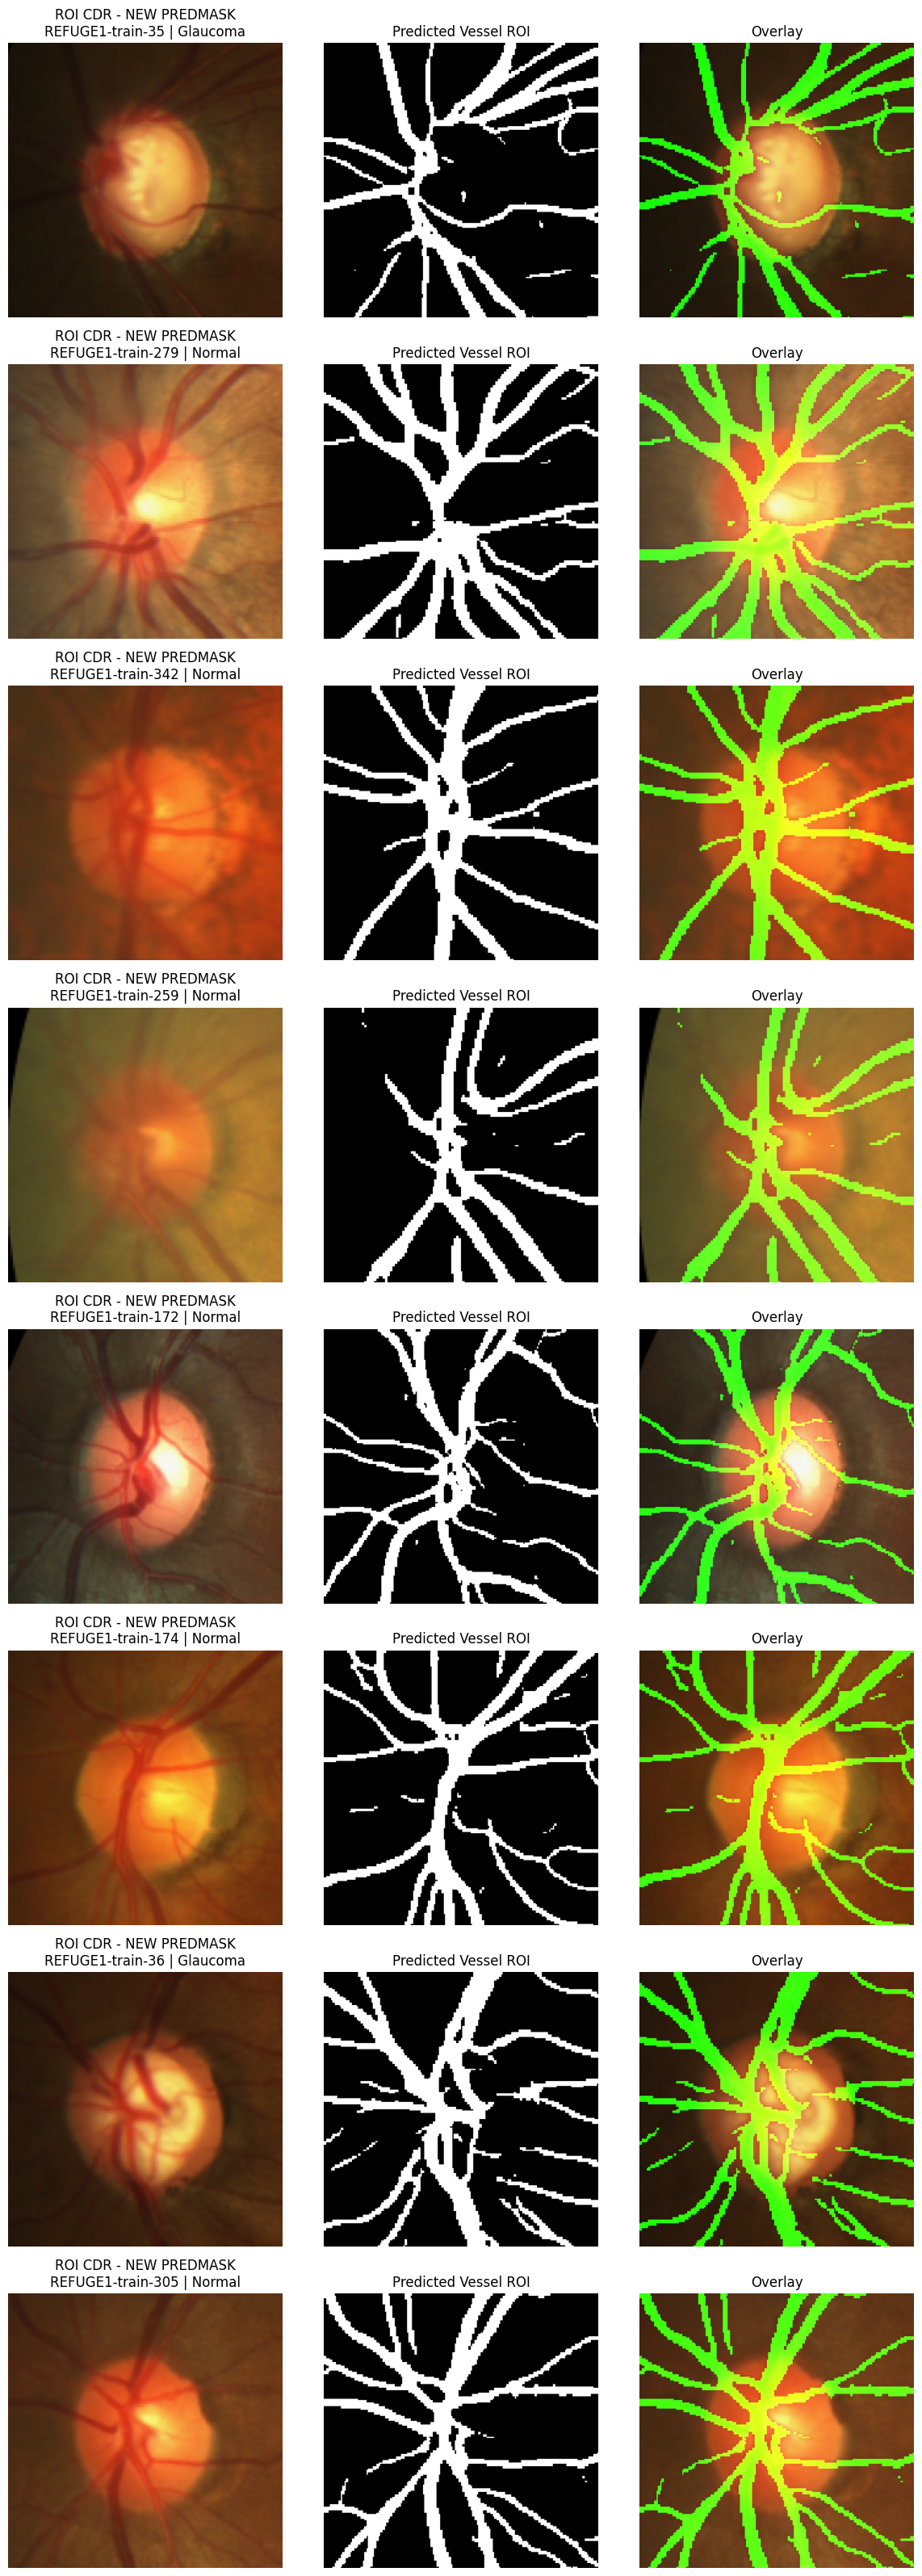

In [ ]:
#preview dataset fusion

def show_fusion_samples_new(n=8, seed=42):
    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(y), size=min(n, len(y)), replace=False)

    plt.figure(figsize=(12, 4 * len(idxs)))

    for i, idx in enumerate(idxs, start=1):
        label_name = "Glaucoma" if y[idx] == 1 else "Normal"

        plt.subplot(len(idxs), 3, (i-1)*3 + 1)
        plt.imshow(np.clip(X_roi[idx] / 255.0, 0, 1))
        plt.title(f"ROI CDR - NEW PREDMASK\n{names[idx]} | {label_name}")
        plt.axis("off")

        plt.subplot(len(idxs), 3, (i-1)*3 + 2)
        plt.imshow(X_vessel[idx].squeeze(), cmap="gray")
        plt.title("Predicted Vessel ROI")
        plt.axis("off")

        overlay = np.clip(X_roi[idx] / 255.0, 0, 1).copy()
        mask = X_vessel[idx].squeeze() > 0
        overlay[mask, 1] = 1.0

        plt.subplot(len(idxs), 3, (i-1)*3 + 3)
        plt.imshow(overlay)
        plt.title("Overlay")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_fusion_samples_new(n=8, seed=42)

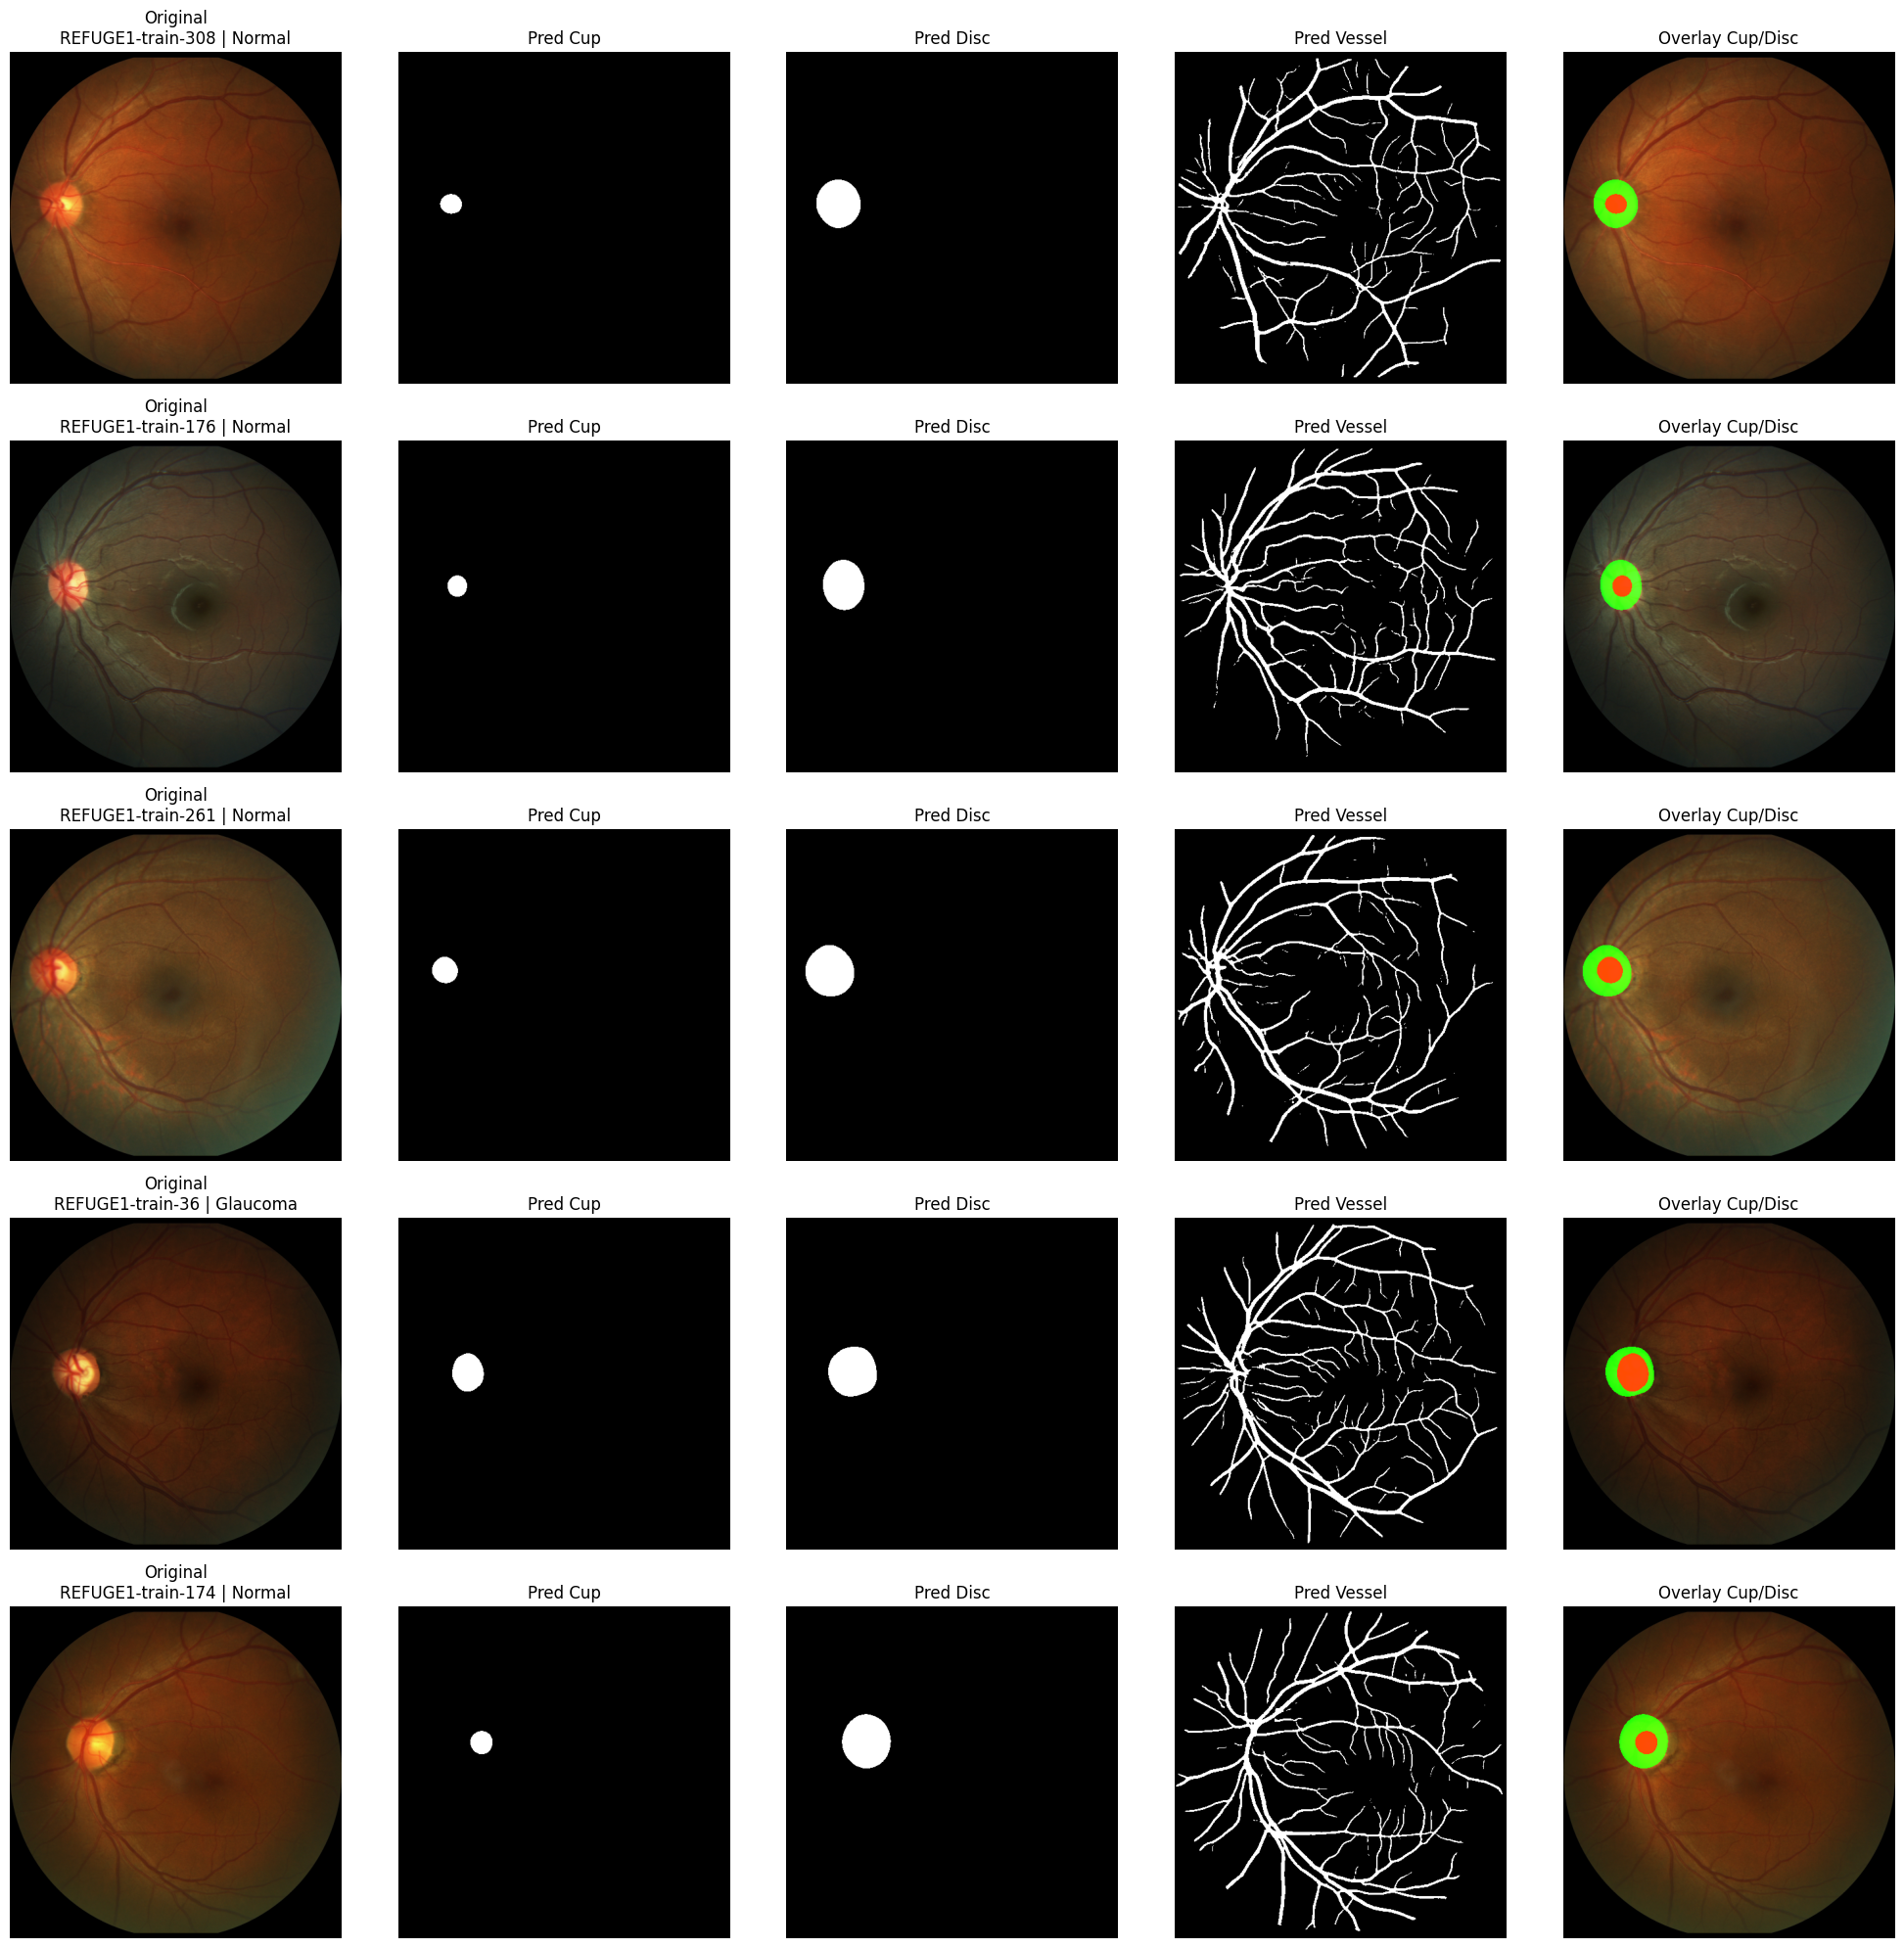

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

def show_pred_cup_disc_preview(n=5, seed=42):
    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(fusion_meta), size=min(n, len(fusion_meta)), replace=False)

    plt.figure(figsize=(20, 4 * len(idxs)))

    for i, idx in enumerate(idxs, start=1):
        row = fusion_meta.iloc[idx]

        name = row["name_no_ext"]
        label_name = "Glaucoma" if int(row["label"]) == 1 else "Normal"

        image_path = row["image_path"]
        cup_path = row["cup_path"]
        disc_path = row["disc_path"]
        vessel_path = row["vessel_pred_path"]

        image = read_rgb(image_path)
        cup = binarize_mask(read_gray(cup_path))
        disc = binarize_mask(read_gray(disc_path))
        vessel = binarize_mask(read_gray(vessel_path))

        h, w = image.shape[:2]

        if cup.shape[:2] != (h, w):
            cup = cv2.resize(cup, (w, h), interpolation=cv2.INTER_NEAREST)

        if disc.shape[:2] != (h, w):
            disc = cv2.resize(disc, (w, h), interpolation=cv2.INTER_NEAREST)

        if vessel.shape[:2] != (h, w):
            vessel = cv2.resize(vessel, (w, h), interpolation=cv2.INTER_NEAREST)

        img_show = np.clip(image / 255.0, 0, 1)

        overlay_cd = img_show.copy()

        disc_mask = disc > 0
        cup_mask = cup > 0

        # disc hijau
        overlay_cd[disc_mask, 1] = 1.0
        overlay_cd[disc_mask, 0] *= 0.4
        overlay_cd[disc_mask, 2] *= 0.4

        # cup merah
        overlay_cd[cup_mask, 0] = 1.0
        overlay_cd[cup_mask, 1] *= 0.3
        overlay_cd[cup_mask, 2] *= 0.3

        plt.subplot(len(idxs), 5, (i-1)*5 + 1)
        plt.imshow(img_show)
        plt.title(f"Original\n{name} | {label_name}")
        plt.axis("off")

        plt.subplot(len(idxs), 5, (i-1)*5 + 2)
        plt.imshow(cup, cmap="gray")
        plt.title("Pred Cup")
        plt.axis("off")

        plt.subplot(len(idxs), 5, (i-1)*5 + 3)
        plt.imshow(disc, cmap="gray")
        plt.title("Pred Disc")
        plt.axis("off")

        plt.subplot(len(idxs), 5, (i-1)*5 + 4)
        plt.imshow(vessel, cmap="gray")
        plt.title("Pred Vessel")
        plt.axis("off")

        plt.subplot(len(idxs), 5, (i-1)*5 + 5)
        plt.imshow(overlay_cd)
        plt.title("Overlay Cup/Disc")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_pred_cup_disc_preview(n=5, seed=42)

In [ ]:
# Simpan preview dataset fusion

preview_path = os.path.join(FUSION_PREVIEW_DIR, "fusion_dataset_preview.png")

rng = np.random.default_rng(123)
idxs = rng.choice(len(y), size=min(12, len(y)), replace=False)

fig = plt.figure(figsize=(12, 4 * len(idxs)))
for i, idx in enumerate(idxs, start=1):
    label_name = "Glaucoma" if y[idx] == 1 else "Normal"

    ax1 = plt.subplot(len(idxs), 3, (i-1)*3 + 1)
    ax1.imshow(np.clip(X_roi[idx] / 255.0, 0, 1))
    ax1.set_title(f"ROI CDR\n{names[idx]} | {label_name}")
    ax1.axis("off")

    ax2 = plt.subplot(len(idxs), 3, (i-1)*3 + 2)
    ax2.imshow(X_vessel[idx].squeeze(), cmap="gray")
    ax2.set_title("Predicted Vessel ROI")
    ax2.axis("off")

    overlay = np.clip(X_roi[idx] / 255.0, 0, 1).copy()
    mask = X_vessel[idx].squeeze() > 0
    overlay[mask, 1] = 1.0

    ax3 = plt.subplot(len(idxs), 3, (i-1)*3 + 3)
    ax3.imshow(overlay)
    ax3.set_title("Overlay")
    ax3.axis("off")

plt.tight_layout()
plt.savefig(preview_path, dpi=200, bbox_inches="tight")
plt.show()
print("Preview saved:", preview_path)


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# augmentasi (oversampling)

def augment_one_sample(roi, vessel):
    roi_aug = roi.copy()
    vessel_aug = vessel.copy()

    if np.random.rand() < 0.5:
        roi_aug = np.flip(roi_aug, axis=1).copy()
        vessel_aug = np.flip(vessel_aug, axis=1).copy()

    alpha = np.random.uniform(0.90, 1.10)
    beta = np.random.uniform(-8, 8)
    roi_aug = roi_aug * alpha + beta

    if np.random.rand() < 0.4:
        noise = np.random.normal(0, 3, roi_aug.shape)
        roi_aug = roi_aug + noise

    roi_aug = np.clip(roi_aug, 0, 255).astype(np.float32)
    vessel_aug = np.clip(vessel_aug, 0, 1).astype(np.float32)
    return roi_aug, vessel_aug

def oversample_minority_glaucoma(X_roi_train, X_vessel_train, X_num_train, y_train, target_ratio=0.70):
    y_train = y_train.astype(np.int32)
    idx_normal = np.where(y_train == 0)[0]
    idx_glaucoma = np.where(y_train == 1)[0]

    n_normal = len(idx_normal)
    n_glaucoma = len(idx_glaucoma)
    target_glaucoma = int(n_normal * target_ratio)

    if n_glaucoma >= target_glaucoma:
        return X_roi_train, X_vessel_train, X_num_train, y_train

    n_add = target_glaucoma - n_glaucoma
    add_indices = np.random.choice(idx_glaucoma, size=n_add, replace=True)

    roi_aug_list = []
    vessel_aug_list = []
    num_aug_list = []
    y_aug_list = []

    for idx in add_indices:
        roi_aug, vessel_aug = augment_one_sample(X_roi_train[idx], X_vessel_train[idx])
        roi_aug_list.append(roi_aug)
        vessel_aug_list.append(vessel_aug)
        num_aug_list.append(X_num_train[idx].copy())
        y_aug_list.append(1)

    X_roi_new = np.concatenate([X_roi_train, np.stack(roi_aug_list)], axis=0)
    X_vessel_new = np.concatenate([X_vessel_train, np.stack(vessel_aug_list)], axis=0)
    X_num_new = np.concatenate([X_num_train, np.stack(num_aug_list)], axis=0)
    y_new = np.concatenate([y_train, np.array(y_aug_list, dtype=np.int32)], axis=0)

    perm = np.random.permutation(len(y_new))
    return X_roi_new[perm], X_vessel_new[perm], X_num_new[perm], y_new[perm]


In [ ]:
#model fusion cnn

def build_roi_branch(roi_input, img_size=224):
    try:
        base = keras.applications.EfficientNetB0(
            include_top=False,
            weights="imagenet",
            input_tensor=roi_input,
            pooling=None,
            name="roi_effnetb0"
        )
        base.trainable = False

        x = base.output
        x = layers.GlobalAveragePooling2D(name="roi_gap")(x)
        x = layers.Dropout(0.30, name="roi_dropout")(x)
        x = layers.Dense(128, activation="relu", name="roi_dense")(x)
        print("ROI branch: EfficientNetB0 ImageNet")
        return x

    except Exception as e:
        print("EfficientNetB0 gagal dimuat. Fallback ke CNN sederhana.")
        print("Error:", e)

        x = layers.Rescaling(1./255)(roi_input)
        x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
        x = layers.MaxPooling2D()(x)
        x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
        x = layers.MaxPooling2D()(x)
        x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
        x = layers.GlobalAveragePooling2D()(x)
        x = layers.Dropout(0.30)(x)
        x = layers.Dense(128, activation="relu")(x)
        return x

def build_fusion_model(img_size=224, num_features=6, lr=1e-4):
    roi_input = keras.Input(shape=(img_size, img_size, 3), name="roi_input")
    vessel_input = keras.Input(shape=(img_size, img_size, 1), name="vessel_input")
    num_input = keras.Input(shape=(num_features,), name="num_input")

    roi_feat = build_roi_branch(roi_input, img_size=img_size)

    v = layers.Conv2D(16, 3, padding="same", activation="relu", name="vessel_conv1")(vessel_input)
    v = layers.BatchNormalization(name="vessel_bn1")(v)
    v = layers.MaxPooling2D(name="vessel_pool1")(v)

    v = layers.Conv2D(32, 3, padding="same", activation="relu", name="vessel_conv2")(v)
    v = layers.BatchNormalization(name="vessel_bn2")(v)
    v = layers.MaxPooling2D(name="vessel_pool2")(v)

    v = layers.Conv2D(64, 3, padding="same", activation="relu", name="vessel_conv3")(v)
    v = layers.BatchNormalization(name="vessel_bn3")(v)
    v = layers.MaxPooling2D(name="vessel_pool3")(v)

    v = layers.Conv2D(128, 3, padding="same", activation="relu", name="vessel_conv4")(v)
    v = layers.GlobalAveragePooling2D(name="vessel_gap")(v)
    v = layers.Dropout(0.30, name="vessel_dropout")(v)
    vessel_feat = layers.Dense(64, activation="relu", name="vessel_dense")(v)

    n = layers.Dense(32, activation="relu", name="num_dense1")(num_input)
    n = layers.Dropout(0.20, name="num_dropout")(n)
    num_feat = layers.Dense(16, activation="relu", name="num_dense2")(n)

    x = layers.Concatenate(name="fusion_concat")([roi_feat, vessel_feat, num_feat])
    x = layers.Dense(128, activation="relu", name="fusion_dense1")(x)
    x = layers.Dropout(0.40, name="fusion_dropout1")(x)
    x = layers.Dense(64, activation="relu", name="fusion_dense2")(x)
    x = layers.Dropout(0.30, name="fusion_dropout2")(x)
    output = layers.Dense(1, activation="sigmoid", name="glaucoma_output")(x)

    model = keras.Model(
        inputs={
            "roi_input": roi_input,
            "vessel_input": vessel_input,
            "num_input": num_input
        },
        outputs=output,
        name="fusion_cdr_vessel_classifier"
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=keras.losses.BinaryCrossentropy(),
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="auc"),
            keras.metrics.AUC(curve="PR", name="pr_auc")
        ]
    )

    return model


In [ ]:
# treshol tuning

def compute_metrics_at_threshold(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    try:
        roc_auc = roc_auc_score(y_true, y_prob)
    except Exception:
        roc_auc = np.nan

    try:
        pr_auc = average_precision_score(y_true, y_prob)
    except Exception:
        pr_auc = np.nan

    return {
        "threshold": float(threshold),
        "accuracy": float(acc),
        "balanced_accuracy": float(bal_acc),
        "precision": float(precision),
        "recall_sensitivity": float(recall),
        "specificity": float(specificity),
        "f1": float(f1),
        "roc_auc": float(roc_auc),
        "pr_auc": float(pr_auc),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp)
    }

def find_best_threshold(y_true, y_prob, target_sensitivity=0.85, min_specificity=0.85):
    """
    Threshold tuning versi lebih seimbang.

    Tujuan:
    - Recall/sensitivity glaucoma tetap tinggi.
    - Specificity normal juga dijaga agar normal tidak terlalu banyak salah menjadi glaucoma.
    - Jika syarat target tidak tercapai, pilih threshold dengan balanced accuracy terbaik
      dan gap sensitivity-specificity paling kecil.
    """
    thresholds = np.round(np.arange(0.05, 0.951, 0.01), 2)
    rows = [compute_metrics_at_threshold(y_true, y_prob, t) for t in thresholds]
    df = pd.DataFrame(rows)

    df["sens_spec_gap"] = np.abs(df["recall_sensitivity"] - df["specificity"])

    candidate = df[
        (df["recall_sensitivity"] >= target_sensitivity) &
        (df["specificity"] >= min_specificity)
    ].copy()

    if len(candidate) > 0:
        candidate = candidate.sort_values(
            by=["balanced_accuracy", "f1", "sens_spec_gap", "specificity"],
            ascending=[False, False, True, False]
        )
        best = candidate.iloc[0].to_dict()
        reason = (
            f"best balanced threshold with sensitivity >= {target_sensitivity} "
            f"and specificity >= {min_specificity}"
        )
    else:
        candidate = df.sort_values(
            by=["balanced_accuracy", "sens_spec_gap", "f1", "specificity"],
            ascending=[False, True, False, False]
        )
        best = candidate.iloc[0].to_dict()
        reason = (
            "best balanced threshold because sensitivity/specificity target "
            "was not reached"
        )

    return best, df, reason

def plot_training_history(history, fold):
    hist = pd.DataFrame(history.history)

    for metric in ["loss", "accuracy", "recall", "auc", "pr_auc"]:
        if metric in hist.columns and f"val_{metric}" in hist.columns:
            plt.figure(figsize=(6, 4))
            plt.plot(hist[metric], label=f"train_{metric}")
            plt.plot(hist[f"val_{metric}"], label=f"val_{metric}")
            plt.title(f"Fold {fold} - {metric}")
            plt.xlabel("Epoch")
            plt.ylabel(metric)
            plt.legend()
            plt.grid(True)
            save_path = os.path.join(PLOT_OUT_DIR, f"fold_{fold}_{metric}.png")
            plt.savefig(save_path, dpi=160, bbox_inches="tight")
            plt.show()


In [ ]:
# stratifiedkfold

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

all_fold_metrics = []
all_threshold_tables = []
all_val_predictions = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_roi, y), start=1):
    print("\n" + "="*80)
    print(f"FOLD {fold}/{N_SPLITS}")
    print("="*80)

    X_roi_train, X_roi_val = X_roi[train_idx], X_roi[val_idx]
    X_vessel_train, X_vessel_val = X_vessel[train_idx], X_vessel[val_idx]
    X_num_train_raw, X_num_val_raw = X_num[train_idx], X_num[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    print("Train label distribution:", pd.Series(y_train).value_counts().sort_index().to_dict())
    print("Val label distribution  :", pd.Series(y_val).value_counts().sort_index().to_dict())

    scaler = StandardScaler()
    X_num_train = scaler.fit_transform(X_num_train_raw).astype(np.float32)
    X_num_val = scaler.transform(X_num_val_raw).astype(np.float32)

    scaler_df = pd.DataFrame({
        "feature": ["ACDR", "VCDR", "HCDR", "vessel_density_roi", "vessel_density_disc", "vessel_density_full"],
        "mean": scaler.mean_,
        "scale": scaler.scale_
    })
    scaler_df.to_csv(os.path.join(METRIC_OUT_DIR, f"fold_{fold}_numeric_scaler.csv"), index=False)

    class_weight = None
    if USE_CLASS_WEIGHT:
        classes = np.array([0, 1])
        weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
        class_weight = {int(c): float(w) for c, w in zip(classes, weights)}
        print("Class weight:", class_weight)

    if USE_OVERSAMPLING_GLAUCOMA:
        X_roi_train, X_vessel_train, X_num_train, y_train = oversample_minority_glaucoma(
            X_roi_train, X_vessel_train, X_num_train, y_train, target_ratio=0.70
        )
        print("After oversampling:", pd.Series(y_train).value_counts().sort_index().to_dict())

    model = build_fusion_model(img_size=IMG_SIZE, num_features=X_num.shape[1], lr=LEARNING_RATE)

    fold_model_path = os.path.join(MODEL_OUT_DIR, f"best_fusion_cdr_vessel_fold_{fold}.keras")
    callbacks = [
        keras.callbacks.ModelCheckpoint(
            fold_model_path,
            monitor="val_pr_auc",
            mode="max",
            save_best_only=True,
            verbose=1
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_pr_auc",
            mode="max",
            patience=8,
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_pr_auc",
            mode="max",
            factor=0.5,
            patience=4,
            min_lr=1e-7,
            verbose=1
        )
    ]

    history = model.fit(
        x={
            "roi_input": X_roi_train,
            "vessel_input": X_vessel_train,
            "num_input": X_num_train
        },
        y=y_train,
        validation_data=(
            {
                "roi_input": X_roi_val,
                "vessel_input": X_vessel_val,
                "num_input": X_num_val
            },
            y_val
        ),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=class_weight,
        callbacks=callbacks,
        verbose=1
    )

    best_model = keras.models.load_model(fold_model_path, compile=False)
    best_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss=keras.losses.BinaryCrossentropy(),
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="auc"),
            keras.metrics.AUC(curve="PR", name="pr_auc")
        ]
    )

    val_prob = best_model.predict(
        {
            "roi_input": X_roi_val,
            "vessel_input": X_vessel_val,
            "num_input": X_num_val
        },
        batch_size=BATCH_SIZE,
        verbose=0
    ).ravel()

    best_thr, thr_table, reason = find_best_threshold(y_val, val_prob, target_sensitivity=TARGET_SENSITIVITY, min_specificity=MIN_SPECIFICITY)
    metrics_05 = compute_metrics_at_threshold(y_val, val_prob, threshold=0.5)

    fold_metrics = {
        "fold": fold,
        "n_train_after_oversampling": len(y_train),
        "n_val": len(y_val),
        "normal_val": int(np.sum(y_val == 0)),
        "glaucoma_val": int(np.sum(y_val == 1)),
        "best_threshold_reason": reason,
        **{f"best_{k}": v for k, v in best_thr.items()},
        **{f"thr05_{k}": v for k, v in metrics_05.items()},
        "model_path": fold_model_path
    }

    all_fold_metrics.append(fold_metrics)

    thr_table["fold"] = fold
    all_threshold_tables.append(thr_table)

    val_pred_df = pd.DataFrame({
        "fold": fold,
        "name_no_ext": names[val_idx],
        "y_true": y_val,
        "y_prob": val_prob,
        "y_pred_best_threshold": (val_prob >= best_thr["threshold"]).astype(int),
        "best_threshold": best_thr["threshold"],
        "y_pred_05": (val_prob >= 0.5).astype(int)
    })
    all_val_predictions.append(val_pred_df)

    cm_best = confusion_matrix(y_val, (val_prob >= best_thr["threshold"]).astype(int), labels=[0, 1])
    cm_05 = confusion_matrix(y_val, (val_prob >= 0.5).astype(int), labels=[0, 1])

    pd.DataFrame(cm_best, index=["true_normal", "true_glaucoma"], columns=["pred_normal", "pred_glaucoma"]).to_csv(
        os.path.join(CM_OUT_DIR, f"fold_{fold}_cm_best_threshold.csv")
    )
    pd.DataFrame(cm_05, index=["true_normal", "true_glaucoma"], columns=["pred_normal", "pred_glaucoma"]).to_csv(
        os.path.join(CM_OUT_DIR, f"fold_{fold}_cm_threshold_05.csv")
    )

    print("\nBest threshold:", best_thr["threshold"], "|", reason)
    print("Best threshold metrics:")
    print(pd.Series(best_thr))

    print("\nThreshold 0.5 metrics:")
    print(pd.Series(metrics_05))

    plot_training_history(history, fold)

fold_metrics_df = pd.DataFrame(all_fold_metrics)
threshold_tables_df = pd.concat(all_threshold_tables, ignore_index=True)
val_predictions_df = pd.concat(all_val_predictions, ignore_index=True)

fold_metrics_path = os.path.join(METRIC_OUT_DIR, "kfold_metrics_summary.csv")
threshold_tables_path = os.path.join(METRIC_OUT_DIR, "threshold_tuning_all_folds.csv")
val_predictions_path = os.path.join(METRIC_OUT_DIR, "validation_predictions_all_folds.csv")

fold_metrics_df.to_csv(fold_metrics_path, index=False)
threshold_tables_df.to_csv(threshold_tables_path, index=False)
val_predictions_df.to_csv(val_predictions_path, index=False)

print("Saved:", fold_metrics_path)
print("Saved:", threshold_tables_path)
print("Saved:", val_predictions_path)

fold_metrics_df


In [ ]:
# hasil kfold

fold_metrics_df = pd.read_csv(os.path.join(METRIC_OUT_DIR, "kfold_metrics_summary.csv"))

summary_cols = [
    "fold",
    "best_threshold",
    "best_accuracy",
    "best_balanced_accuracy",
    "best_precision",
    "best_recall_sensitivity",
    "best_specificity",
    "best_f1",
    "best_roc_auc",
    "best_pr_auc",
    "best_tn",
    "best_fp",
    "best_fn",
    "best_tp"
]

display_df = fold_metrics_df[summary_cols].copy()
display(display_df)

mean_cols = [
    "best_accuracy",
    "best_balanced_accuracy",
    "best_precision",
    "best_recall_sensitivity",
    "best_specificity",
    "best_f1",
    "best_roc_auc",
    "best_pr_auc",
    "best_fn",
    "best_fp"
]

summary_mean = display_df[mean_cols].mean(numeric_only=True)
summary_std = display_df[mean_cols].std(numeric_only=True)

summary_result = pd.DataFrame({
    "mean": summary_mean,
    "std": summary_std
})

summary_result_path = os.path.join(METRIC_OUT_DIR, "kfold_metrics_mean_std.csv")
summary_result.to_csv(summary_result_path)

print("Mean ± Std saved:", summary_result_path)
display(summary_result)


In [ ]:
val_predictions_df = pd.read_csv(os.path.join(METRIC_OUT_DIR, "validation_predictions_all_folds.csv"))

cm_total = confusion_matrix(
    val_predictions_df["y_true"],
    val_predictions_df["y_pred_best_threshold"],
    labels=[0, 1]
)

cm_total_df = pd.DataFrame(
    cm_total,
    index=["true_normal", "true_glaucoma"],
    columns=["pred_normal", "pred_glaucoma"]
)

cm_total_path = os.path.join(CM_OUT_DIR, "overall_cm_best_threshold.csv")
cm_total_df.to_csv(cm_total_path)

print("Overall confusion matrix saved:", cm_total_path)
display(cm_total_df)

tn, fp, fn, tp = cm_total.ravel()
overall_sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
overall_specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print("Overall sensitivity/recall glaucoma:", overall_sensitivity)
print("Overall specificity:", overall_specificity)
print("Total false negative glaucoma:", fn)


In [ ]:
# model terbaik

ranking_df = fold_metrics_df.copy()
ranking_df = ranking_df.sort_values(
    by=["best_fn", "best_recall_sensitivity", "best_pr_auc", "best_f1"],
    ascending=[True, False, False, False]
)

best_row = ranking_df.iloc[0]
best_fold = int(best_row["fold"])
best_model_path = best_row["model_path"]
best_threshold = float(best_row["best_threshold"])

best_info = {
    "best_fold": best_fold,
    "best_model_path": best_model_path,
    "best_threshold": best_threshold,
    "selection_rule": "min false negative, max sensitivity, max PR-AUC, max F1"
}

best_info_path = os.path.join(METRIC_OUT_DIR, "best_model_info.json")
with open(best_info_path, "w") as f:
    json.dump(best_info, f, indent=4)

print("Best model info:")
print(json.dumps(best_info, indent=4))
print("Saved:", best_info_path)


In [ ]:
# simpan path

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


BASE_DIR = "/content/drive/MyDrive/BV_CDR"

OUTPUT_ROOT = os.path.join(BASE_DIR, "Klasifikasi_EFFB4")

CM_PATH = os.path.join(
    OUTPUT_ROOT,
    "results",
    "confusion_matrix",
    "overall_cm_best_threshold.csv"
)

VAL_PRED_PATH = os.path.join(
    OUTPUT_ROOT,
    "results",
    "metrics",
    "validation_predictions_all_folds.csv"
)

SAVE_DIR = os.path.join(
    OUTPUT_ROOT,
    "results",
    "plots"
)

os.makedirs(SAVE_DIR, exist_ok=True)

print("CM_PATH:", CM_PATH)
print("VAL_PRED_PATH:", VAL_PRED_PATH)
print("SAVE_DIR:", SAVE_DIR)


print("\nCek file:")
print("CM ada?      :", os.path.exists(CM_PATH))
print("Val pred ada?:", os.path.exists(VAL_PRED_PATH))

assert os.path.exists(CM_PATH) or os.path.exists(VAL_PRED_PATH), (
    "File hasil evaluasi model baru belum ditemukan. "
    "Kemungkinan training/evaluasi model predmask belum dijalankan."
)

if os.path.exists(CM_PATH):
    print("\nLoad confusion matrix dari:")
    print(CM_PATH)

    cm_df = pd.read_csv(CM_PATH, index_col=0)
    cm = cm_df.values

else:
    print("\noverall_cm_best_threshold.csv belum ditemukan.")
    print("Membuat confusion matrix dari validation_predictions_all_folds.csv:")
    print(VAL_PRED_PATH)

    pred_df = pd.read_csv(VAL_PRED_PATH)

    y_true = pred_df["y_true"].values
    y_pred = pred_df["y_pred_best_threshold"].values

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

# Format confusion matrix:
# [[TN, FP],
#  [FN, TP]]
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix:")
print(cm)

print()
print("Normal terdeteksi Normal        :", tn)
print("Normal salah terdeteksi Glaucoma:", fp)
print("Glaucoma salah terdeteksi Normal:", fn)
print("Glaucoma terdeteksi Glaucoma    :", tp)


sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
accuracy = (tp + tn) / (tp + tn + fp + fn)

print()
print("Accuracy                    :", round(accuracy, 4))
print("Sensitivity / Recall Glaucoma:", round(sensitivity, 4))
print("Specificity / Recall Normal  :", round(specificity, 4))


labels = ["Normal", "Glaucoma"]

plt.figure(figsize=(7, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix - REFUGE Fusion CDR + Vessel Predmask")
plt.colorbar()

tick_marks = np.arange(len(labels))
plt.xticks(tick_marks, labels)
plt.yticks(tick_marks, labels)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            fontsize=14,
            fontweight="bold"
        )

plt.tight_layout()

cm_save_path = os.path.join(SAVE_DIR, "overall_confusion_matrix_best_threshold_predmask.png")
plt.savefig(cm_save_path, dpi=200, bbox_inches="tight")
plt.show()

print("\nConfusion matrix disimpan di:")
print(cm_save_path)

correct_labels = [
    "Normal terdeteksi Normal",
    "Glaucoma terdeteksi Glaucoma"
]

correct_values = [tn, tp]

plt.figure(figsize=(8, 5))
bars = plt.bar(correct_labels, correct_values)

plt.title("Jumlah Prediksi Benar per Kelas - Predmask")
plt.ylabel("Jumlah Data")
plt.xlabel("Kategori Prediksi Benar")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        str(int(height)),
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

plt.tight_layout()

bar_save_path = os.path.join(SAVE_DIR, "correct_detection_normal_glaucoma_predmask.png")
plt.savefig(bar_save_path, dpi=200, bbox_inches="tight")
plt.show()

print("\nGrafik prediksi benar disimpan di:")
print(bar_save_path)

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


BASE_DIR = "/content/drive/MyDrive/BV_CDR"

OUTPUT_ROOT = os.path.join(BASE_DIR, "Klasifikasi_EFFB4")

PRED_PATH = os.path.join(
    OUTPUT_ROOT,
    "results",
    "metrics",
    "validation_predictions_all_folds.csv"
)

PLOT_DIR = os.path.join(
    OUTPUT_ROOT,
    "results",
    "plots"
)

METRIC_DIR = os.path.join(
    OUTPUT_ROOT,
    "results",
    "metrics"
)

os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(METRIC_DIR, exist_ok=True)

df = pd.read_csv(PRED_PATH)

print("Kolom tersedia:")
print(df.columns.tolist())


y_true = df["y_true"].values
y_pred = df["y_pred_best_threshold"].values


label_names = {
    0: "Normal",
    1: "Glaucoma"
}

rows = []

for label_value, label_name in label_names.items():
    # One-vs-rest
    y_true_binary = (y_true == label_value).astype(int)
    y_pred_binary = (y_pred == label_value).astype(int)

    cm = confusion_matrix(y_true_binary, y_pred_binary, labels=[0, 1])

    # Format:
    # [[TN, FP],
    #  [FN, TP]]
    tn, fp, fn, tp = cm.ravel()

    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score = (2 * tp) / ((2 * tp) + fp + fn) if ((2 * tp) + fp + fn) > 0 else 0

    rows.append({
        "label": label_name,
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "accuracy": accuracy,
        "specificity": specificity,
        "recall": recall,
        "f1_score": f1_score
    })

metrics_per_label = pd.DataFrame(rows)

metrics_display = metrics_per_label.copy()
for col in ["accuracy", "specificity", "recall"]:
    metrics_display[col] = metrics_display[col] * 100

metrics_display = metrics_display.round(2)
metrics_display = metrics_display.drop(columns=["f1_score"])

print("Metrik terbaik per label:")
display(metrics_display)


csv_path = os.path.join(METRIC_DIR, "best_threshold_metrics_per_label.csv")
metrics_display.to_csv(csv_path, index=False)

print("Tabel metrik disimpan di:")
print(csv_path)


plot_df = metrics_display[[
    "label",
    "accuracy",
    "specificity",
    "recall",
]].copy()

x = np.arange(len(plot_df["label"]))
width = 0.20

plt.figure(figsize=(10, 6))

bars1 = plt.bar(x - 1.5 * width, plot_df["accuracy"], width, label="Accuracy")
bars2 = plt.bar(x - 0.5 * width, plot_df["specificity"], width, label="Specificity")
bars3 = plt.bar(x + 0.5 * width, plot_df["recall"], width, label="Recall")

plt.xticks(x, plot_df["label"])
plt.ylabel("Nilai (%)")
plt.xlabel("Label")
plt.title("Metrik Terbaik per Label Berdasarkan Best Threshold")
plt.ylim(0, 105)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)


for bars in [bars1, bars2, bars3]: # Removed bars4 as it was undefined
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f"{height:.1f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()

plot_path = os.path.join(PLOT_DIR, "best_threshold_metrics_per_label.png")
plt.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("Grafik metrik per label disimpan di:")
print(plot_path)

output file:


```text
/content/drive/MyDrive/BV_CDR/Klasifikasi_EFFB4/
├── processed/
│   └── refuge_fusion_predmask_efficientnetb4/
│       ├── refuge_fusion_dataset_224_predmask_efficientnetb4.npz
│       ├── refuge_fusion_metadata_predmask_efficientnetb4.csv
│       └── previews/
├── models/
│   ├── best_fusion_cdr_vessel_fold_1.keras
│   ├── best_fusion_cdr_vessel_fold_2.keras
│   └── ...
└── results/
    ├── metrics/
    ├── plots/
    └── confusion_matrix/
```